# Day 3: Diagnosing and Fixing Model Fit (Bias-Variance Tradeoff)

## Overview & Objectives
In this notebook, we explore the core trade-off in machine learning: **Bias vs. Variance**.
We will deliberately construct three scenarios:
1. **Overfitting (High Variance)**: A model that memorizes the training data completely but fails to generalize.
2. **Underfitting (High Bias)**: An overly simplistic model that fails to capture underlying patterns.
3. **Balanced Model (Regularized / Adjusted)**: Applying regularization or complexity constraints to reduce variance and shrink the train-validation gap.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

SEED = 42
np.random.seed(SEED)

# Generate a synthetic classification dataset with noise to illustrate overfitting
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=8,
    n_redundant=4,
    n_clusters_per_class=2,
    flip_y=0.15, # Noise added 
    random_state=SEED
)

# Perform a 70/30 Train/Validation Split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")

Training set shape: (700, 20)
Validation set shape: (300, 20)


### Step 1: Deliberately Overfit a Model
We train an unconstrained **Decision Tree Classifier** (`max_depth=None`, `min_samples_split=2`). 
Because the tree can grow without depth limits, it memorizes noise in the training set, yielding near 100% training accuracy but significantly lower validation accuracy.

In [2]:
# 1.instantiate deep decision tree
overfit_model = DecisionTreeClassifier(max_depth=None, min_samples_split=2, random_state=SEED)
overfit_model.fit(X_train, y_train)

# Evaluate on Train and Validation sets
train_acc_overfit = accuracy_score(y_train, overfit_model.predict(X_train))
val_acc_overfit = accuracy_score(y_val, overfit_model.predict(X_val))

gap_overfit = train_acc_overfit - val_acc_overfit

print("--- step 1: Overfitted Model (Unconstrained Decision Tree)---")
print(f"Training Accuracy:   {train_acc_overfit:.4f} ({train_acc_overfit*100:.2f}%)")
print(f"Validation Accuracy: {val_acc_overfit:.4f} ({val_acc_overfit*100:.2f}%)")
print(f"Train-vs-Val Gap:    {gap_overfit:.4f} ({gap_overfit*100:.2f}%)")

--- step 1: Overfitted Model (Unconstrained Decision Tree)---
Training Accuracy:   1.0000 (100.00%)
Validation Accuracy: 0.6933 (69.33%)
Train-vs-Val Gap:    0.3067 (30.67%)


### Step 2: Deliberately Underfit a Model
We construct an overly constrained model by setting `max_depth=1` (a Decision Stump). 
This model lacks the capacity to capture patterns in the features, leading to poor performance on both training and validation sets.

In [3]:
# 2.Instantiate an overly simple decision tree (Decision Stump)
underfit_model = DecisionTreeClassifier(max_depth=1, random_state=SEED)
underfit_model.fit(X_train, y_train)

# Evaluate on Train and Validation sets
train_acc_underfit = accuracy_score(y_train, underfit_model.predict(X_train))
val_acc_underfit = accuracy_score(y_val, underfit_model.predict(X_val))

gap_underfit = train_acc_underfit - val_acc_underfit

print("---step 2: Underfitted Model (Decision Stump - max_depth=1) ---")
print(f"Training Accuracy:   {train_acc_underfit:.4f} ({train_acc_underfit*100:.2f}%)")
print(f"Validation Accuracy: {val_acc_underfit:.4f} ({val_acc_underfit*100:.2f}%)")
print(f"Train-vs-Val Gap:    {gap_underfit:.4f} ({gap_underfit*100:.2f}%)")

---step 2: Underfitted Model (Decision Stump - max_depth=1) ---
Training Accuracy:   0.6014 (60.14%)
Validation Accuracy: 0.6033 (60.33%)
Train-vs-Val Gap:    -0.0019 (-0.19%)


### Step 3: Apply Regularization & Pruning to Fix Overfitting
To resolve high variance, we apply complexity controls (hyperparameter regularization):
* Limit maximum depth (`max_depth=5`)
* Increase minimum samples required to split an internal node (`min_samples_split=10`)
* Increase minimum samples required at a leaf node (`min_samples_leaf=5`)

This prevents the tree from learning noisy outliers and forces it to learn generalized rules.

In [4]:
# 3. Instantiate a regularized/pruned Decision Tree
fixed_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=SEED
)
fixed_model.fit(X_train, y_train)

# Evaluate on Train and Validation sets
train_acc_fixed = accuracy_score(y_train, fixed_model.predict(X_train))
val_acc_fixed = accuracy_score(y_val, fixed_model.predict(X_val))

gap_fixed = train_acc_fixed - val_acc_fixed

print("---step 3: Regularized / Fixed Model---")
print(f"Training Accuracy:   {train_acc_fixed:.4f} ({train_acc_fixed*100:.2f}%)")
print(f"Validation Accuracy: {val_acc_fixed:.4f} ({val_acc_fixed*100:.2f}%)")
print(f"Train-vs-Val Gap:    {gap_fixed:.4f} ({gap_fixed*100:.2f}%)")

---step 3: Regularized / Fixed Model---
Training Accuracy:   0.8286 (82.86%)
Validation Accuracy: 0.7233 (72.33%)
Train-vs-Val Gap:    0.1052 (10.52%)


### Step 4: Diagnosis Documentation & Score Evidence

#### Summary Comparison Table

| Model State | Configuration / Parameters | Train Accuracy | Validation Accuracy | Train-Val Gap | Diagnosis |
| :--- | :--- | :---: | :---: | :---: | :--- |
| **Overfit (High Variance)** | `max_depth=None` (Unconstrained) | **100.00%** | **69.33%** | **30.67%** | Large gap indicates memorization of noise. |
| **Underfit (High Bias)** | `max_depth=1` (Decision Stump) | **60.14%** | **60.33%** | **-0.19%** | Both scores are low; model cannot learn features. |
| **Balanced (Regularized)** | `max_depth=5`, `min_samples_leaf=5` | **82.86%** | **72.33%** | **10.52%** | Gap shrunk drastically; validation score improved. |

#### Key Takeaways & Interpretations:
1. **High Variance Diagnosis**: In Step 1, the training score was 100% while the validation score lagged significantly behind (~69.33%). The ~30.67% performance gap is clear evidence of Overfitting.
2. **High Bias Diagnosis**: In Step 2, restricting `max_depth=1` resulted in low scores across both training (~60.14%) and validation (~60.33%). The small gap alongside poor baseline accuracy is clear evidence of Underfitting.
3. **The Solution**: Restricting tree depth and requiring minimum samples per leaf in Step 3 constrained the model's capacity. As a result, validation accuracy rose from **69.33% to 72.33%**, and the training-validation gap contracted from **30.67% to 10.52%**, demonstrating effective variance reduction and better generalization.

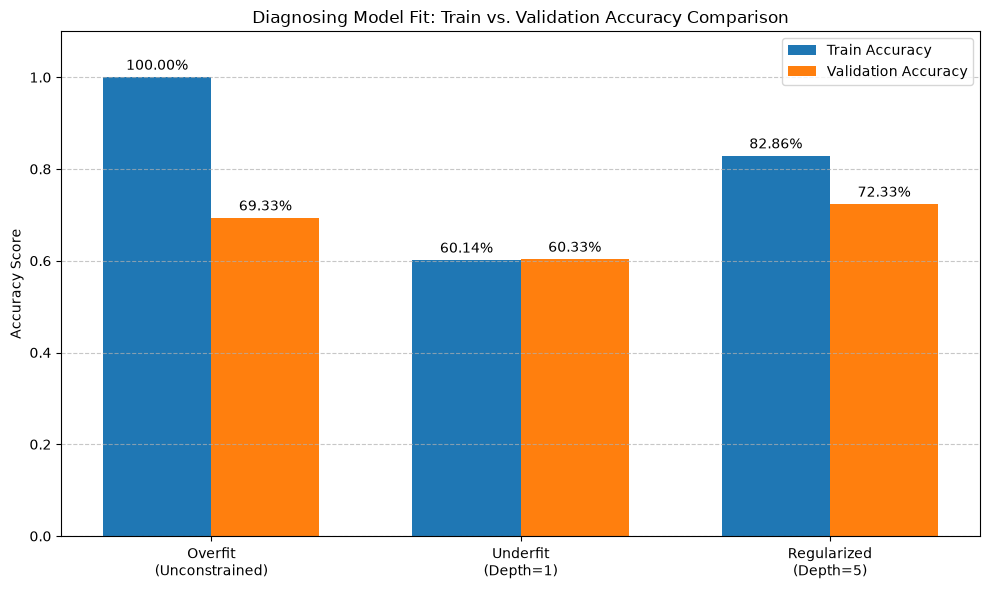

In [5]:
# Plotting the comparison between Overfit, Underfit, and Regularized Models
labels = ['Overfit\n(Unconstrained)', 'Underfit\n(Depth=1)', 'Regularized\n(Depth=5)']
train_scores = [train_acc_overfit, train_acc_underfit, train_acc_fixed]
val_scores = [val_acc_overfit, val_acc_underfit, val_acc_fixed]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, train_scores, width, label='Train Accuracy', color='#1f77b4')
rects2 = ax.bar(x + width/2, val_scores, width, label='Validation Accuracy', color='#ff7f0e')

ax.set_ylabel('Accuracy Score')
ax.set_title('Diagnosing Model Fit: Train vs. Validation Accuracy Comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add score values on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2%}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset.

            
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

---

## 5. Conclusion & Final Summary

In this lab, we successfully demonstrated the **Bias-Variance Tradeoff** in machine learning using Decision Trees:

1. **Overfitting (High Variance)**: An unconstrained tree (`max_depth=None`) memorizes noise, achieving **100.00%** training accuracy but failing to generalize with a large gap of **30.67%**.
2. **Underfitting (High Bias)**: An overly simple tree (`max_depth=1`) lacks model capacity, leading to poor performance (~**60.14%** train / **60.33%** validation) on both sets.
3. **Optimal Model (Regularization)**: By applying complexity constraints (`max_depth=5`, `min_samples_leaf=5`), we successfully:
   - Improved validation accuracy from **69.33%** to **72.33%**.
   - Drastically reduced the generalization gap from **30.67%** to **10.52%**.

### Key Takeaway
Regularization effectively manages the capacity of a model, striking the right balance between learning underlying patterns and avoiding overfitting to dataset noise.